In [1]:
import pandas as pd
import matplotlib as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


# 1. COUNTRY NAME MAPPING

# ACLED countries:
# Bahrain, Iran, Iraq, Israel, Jordan, Kuwait, Lebanon,
# Oman, Palestine, Qatar, Saudi Arabia, Syria, Turkey,
# United Arab Emirates, Yemen

# Mapping: source_name -> ACLED_name
SIPRI_TO_ACLED = {
    'Bahrain': 'Bahrain',
    'Iran': 'Iran',
    'Iraq': 'Iraq',
    'Israel': 'Israel',
    'Jordan': 'Jordan',
    'Kuwait': 'Kuwait',
    'Lebanon': 'Lebanon',
    'Oman': 'Oman',
    'Qatar': 'Qatar',
    'Saudi Arabia': 'Saudi Arabia',
    'Syria': 'Syria',
    'Türkiye': 'Turkey',
    'United Arab Emirates': 'United Arab Emirates',
    'Yemen': 'Yemen',
}

CLASS_TO_ACLED = {
    'Bahrain': 'Bahrain',
    'Iran, Islamic Rep.': 'Iran',
    'Iraq': 'Iraq',
    'Israel': 'Israel',
    'Jordan': 'Jordan',
    'Kuwait': 'Kuwait',
    'Lebanon': 'Lebanon',
    'Oman': 'Oman',
    'West Bank and Gaza': 'Palestine',
    'Qatar': 'Qatar',
    'Saudi Arabia': 'Saudi Arabia',
    'Syrian Arab Republic': 'Syria',
    'Yemen, Rep.': 'Yemen',
    'United Arab Emirates': 'United Arab Emirates',
}

WB_TO_ACLED = {
    'Bahrain': 'Bahrain',
    'Iran, Islamic Rep.': 'Iran',
    'Iraq': 'Iraq',
    'Israel': 'Israel',
    'Jordan': 'Jordan',
    'Kuwait': 'Kuwait',
    'Lebanon': 'Lebanon',
    'Oman': 'Oman',
    'West Bank and Gaza': 'Palestine',
    'Qatar': 'Qatar',
    'Saudi Arabia': 'Saudi Arabia',
    'Syrian Arab Republic': 'Syria',
    'Turkey': 'Turkey',  # World Bank uses "Turkey" not "Türkiye"
    'Yemen, Rep.': 'Yemen',
    'United Arab Emirates': 'United Arab Emirates',
}

# Target countries (ACLED Middle East)
TARGET_COUNTRIES = [
    'Bahrain', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait',
    'Lebanon', 'Oman', 'Palestine', 'Qatar', 'Saudi Arabia',
    'Syria', 'Turkey', 'United Arab Emirates', 'Yemen'
]

# Load ACLED data
print("=" * 60)
print("Loading ACLED Middle East Conflict Data...")
print("=" * 60)

acled = pd.read_excel('../Data/Middle-East_aggregated_data_up_to-2026-03-07.xlsx')

# Parse date and extract year
acled['WEEK'] = pd.to_datetime(acled['WEEK'])
acled['YEAR'] = acled['WEEK'].dt.year

print(f"  Shape: {acled.shape}")
print(f"  Date range: {acled['WEEK'].min().date()} to {acled['WEEK'].max().date()}")
print(f"  Countries: {acled['COUNTRY'].nunique()}")


Loading ACLED Middle East Conflict Data...
  Shape: (144526, 14)
  Date range: 2014-12-27 to 2026-03-07
  Countries: 15


In [2]:
# Aggregate ACLED to country-year level for merging with annual data
acled_annual = acled.groupby(['COUNTRY', 'YEAR']).agg(
    total_events=('EVENTS', 'sum'),
    total_fatalities=('FATALITIES', 'sum'),
    avg_population_exposure=('POPULATION_EXPOSURE', 'mean'),
    num_weeks_with_events=('WEEK', 'nunique'),
    num_event_types=('EVENT_TYPE', 'nunique'),
    num_admin_regions=('ADMIN1', 'nunique'),
).reset_index()

print(f"\n  Annual aggregation shape: {acled_annual.shape}")
print(acled_annual.head())


  Annual aggregation shape: (170, 8)
   COUNTRY  YEAR  total_events  total_fatalities  avg_population_exposure  \
0  Bahrain  2015            12                 0             30567.333333   
1  Bahrain  2016          3212                 5             66364.878282   
2  Bahrain  2017          3744                17             67362.066986   
3  Bahrain  2018          1602                 0             58122.277027   
4  Bahrain  2019           715                 1             35209.654867   

   num_weeks_with_events  num_event_types  num_admin_regions  
0                      1                2                  3  
1                     53                6                  4  
2                     52                6                  4  
3                     52                4                  4  
4                     52                4                  4  


In [4]:

#  LOAD SIPRI DATA (all sheets)
print("\n" + "=" * 60)
print("Loading SIPRI Military Expenditure Data...")
print("=" * 60)

def load_sipri_sheet(filepath, sheet_name, header_row, value_name):
    """Load a SIPRI sheet, melt from wide to long format, filter to target countries."""
    df = pd.read_excel(filepath, sheet_name=sheet_name, header=header_row)
    
    # Drop the 'Notes' column if it exists
    if 'Notes' in df.columns:
        df = df.drop(columns=['Notes'])
    
    # Keep only rows where Country is in our mapping
    df = df[df['Country'].isin(SIPRI_TO_ACLED.keys())].copy()
    
    # Map to ACLED names
    df['Country'] = df['Country'].map(SIPRI_TO_ACLED)
    
    # Melt from wide to long
    year_cols = [c for c in df.columns if c != 'Country']
    df_long = df.melt(id_vars='Country', value_vars=year_cols,
                       var_name='YEAR', value_name=value_name)
    
    # Clean year column
    df_long['YEAR'] = pd.to_numeric(df_long['YEAR'], errors='coerce')
    df_long = df_long.dropna(subset=['YEAR'])
    df_long['YEAR'] = df_long['YEAR'].astype(int)
    
    # Replace '..' and 'xxx' with NaN, convert to numeric
    df_long[value_name] = pd.to_numeric(df_long[value_name], errors='coerce')
    
    return df_long

sipri_file = '../Data/SIPRI-Milex-data-1949-2025.xlsx'

# Constant (2024) US$ — total military spending
sipri_constant = load_sipri_sheet(sipri_file, 'Constant (2024) US$', 5, 'milex_constant_usd_m')
print(f"  Constant USD shape: {sipri_constant.shape}")

# Per capita spending
sipri_percapita = load_sipri_sheet(sipri_file, 'Per capita', 6, 'milex_per_capita')
print(f"  Per capita shape: {sipri_percapita.shape}")

# Share of GDP
sipri_gdp = load_sipri_sheet(sipri_file, 'Share of GDP', 5, 'milex_share_gdp')
print(f"  Share of GDP shape: {sipri_gdp.shape}")

# Current US$
sipri_current = load_sipri_sheet(sipri_file, 'Current US$', 5, 'milex_current_usd_m')
print(f"  Current USD shape: {sipri_current.shape}")

# Merge all SIPRI sheets together
sipri_merged = sipri_constant.merge(
    sipri_percapita, on=['Country', 'YEAR'], how='outer'
).merge(
    sipri_gdp, on=['Country', 'YEAR'], how='outer'
).merge(
    sipri_current, on=['Country', 'YEAR'], how='outer'
)

sipri_merged.rename(columns={'Country': 'COUNTRY'}, inplace=True)
print(f"\n  Merged SIPRI shape: {sipri_merged.shape}")
print(sipri_merged.head())


Loading SIPRI Military Expenditure Data...
  Constant USD shape: (1064, 3)
  Per capita shape: (518, 3)
  Share of GDP shape: (1064, 3)
  Current USD shape: (1064, 3)

  Merged SIPRI shape: (1064, 6)
   COUNTRY  YEAR  milex_constant_usd_m  milex_per_capita  milex_share_gdp  \
0  Bahrain  1949                   NaN               NaN              NaN   
1  Bahrain  1950                   NaN               NaN              NaN   
2  Bahrain  1951                   NaN               NaN              NaN   
3  Bahrain  1952                   NaN               NaN              NaN   
4  Bahrain  1953                   NaN               NaN              NaN   

   milex_current_usd_m  
0                  NaN  
1                  NaN  
2                  NaN  
3                  NaN  
4                  NaN  


In [6]:

# LOAD WORLD BANK HISTORICAL CLASSIFICATIONS
print("\n" + "=" * 60)
print("Loading World Bank Historical Income Classifications...")
print("=" * 60)

wb_hist = pd.read_excel('../Data/World_bank_hist.xlsx', header=1)

# Rename first column
wb_hist.rename(columns={wb_hist.columns[0]: 'Country'}, inplace=True)

# Filter to target countries
wb_hist = wb_hist[wb_hist['Country'].isin(WB_TO_ACLED.keys())].copy()
wb_hist['Country'] = wb_hist['Country'].map(WB_TO_ACLED)

# Melt to long format
# Column names are like FY89, FY90, ..., FY26
fy_cols = [c for c in wb_hist.columns if str(c).startswith('FY')]
wb_long = wb_hist.melt(id_vars='Country', value_vars=fy_cols,
                        var_name='FY', value_name='income_classification')

# Convert FY to calendar year (FY89 -> 1989, FY00 -> 2000, FY26 -> 2026)
def fy_to_year(fy):
    num = int(fy.replace('FY', ''))
    if num >= 89:
        return 1900 + num
    else:
        return 2000 + num

wb_long['YEAR'] = wb_long['FY'].apply(fy_to_year)
wb_long = wb_long.drop(columns=['FY'])

# Replace '..' with NaN
wb_long['income_classification'] = wb_long['income_classification'].replace('..', np.nan)

wb_long.rename(columns={'Country': 'COUNTRY'}, inplace=True)
print(f"  Shape: {wb_long.shape}")
print(wb_long.head())



Loading World Bank Historical Income Classifications...
  Shape: (532, 3)
   COUNTRY income_classification  YEAR
0  Bahrain                     H  1989
1     Iran                    UM  1989
2     Iraq                    UM  1989
3   Israel                     H  1989
4   Jordan                    LM  1989


In [7]:
# LOAD CURRENT WORLD BANK CLASSIFICATIONS (CLASS)
print("\n" + "=" * 60)
print("Loading Current World Bank Classifications...")
print("=" * 60)

class_df = pd.read_excel('../Data/CLASS_2025_10_07.xlsx', sheet_name='List of economies', header=0)

# Filter to target countries
class_df = class_df[class_df['Economy'].isin(CLASS_TO_ACLED.keys())].copy()
class_df['COUNTRY'] = class_df['Economy'].map(CLASS_TO_ACLED)

# Keep relevant columns
class_df = class_df[['COUNTRY', 'Code', 'Region', 'Income group', 'Lending category']].copy()
class_df.rename(columns={
    'Code': 'iso_code',
    'Region': 'wb_region',
    'Income group': 'current_income_group',
    'Lending category': 'lending_category'
}, inplace=True)

print(f"  Shape: {class_df.shape}")
print(class_df.to_string())


Loading Current World Bank Classifications...
  Shape: (14, 5)
                  COUNTRY iso_code                                          wb_region current_income_group lending_category
14                Bahrain      BHR  Middle East, North Africa, Afghanistan & Pakistan          High income              NaN
91                   Iran      IRN  Middle East, North Africa, Afghanistan & Pakistan  Upper middle income             IBRD
92                   Iraq      IRQ  Middle East, North Africa, Afghanistan & Pakistan  Upper middle income             IBRD
95                 Israel      ISR  Middle East, North Africa, Afghanistan & Pakistan          High income              NaN
99                 Jordan      JOR  Middle East, North Africa, Afghanistan & Pakistan  Lower middle income             IBRD
106                Kuwait      KWT  Middle East, North Africa, Afghanistan & Pakistan          High income              NaN
110               Lebanon      LBN  Middle East, North Africa, Afgha

In [8]:
# BUILD COUNTRY DIMENSION TABLE
print("\n" + "=" * 60)
print("Building Country Dimension Table...")
print("=" * 60)

# Create country table with IDs
country_table = pd.DataFrame({'COUNTRY': TARGET_COUNTRIES})
country_table['country_id'] = range(1, len(country_table) + 1)

# Merge in CLASS info
country_table = country_table.merge(class_df, on='COUNTRY', how='left')

print(country_table.to_string())


Building Country Dimension Table...
                 COUNTRY  country_id iso_code                                          wb_region current_income_group lending_category
0                Bahrain           1      BHR  Middle East, North Africa, Afghanistan & Pakistan          High income              NaN
1                   Iran           2      IRN  Middle East, North Africa, Afghanistan & Pakistan  Upper middle income             IBRD
2                   Iraq           3      IRQ  Middle East, North Africa, Afghanistan & Pakistan  Upper middle income             IBRD
3                 Israel           4      ISR  Middle East, North Africa, Afghanistan & Pakistan          High income              NaN
4                 Jordan           5      JOR  Middle East, North Africa, Afghanistan & Pakistan  Lower middle income             IBRD
5                 Kuwait           6      KWT  Middle East, North Africa, Afghanistan & Pakistan          High income              NaN
6                L

In [9]:
# Merge to master dataset
print("\n" + "=" * 60)
print("Building Master Dataset (Country-Year level)...")
print("=" * 60)

# Start with ACLED annual
master = acled_annual.copy()

# Merge SIPRI
master = master.merge(sipri_merged, on=['COUNTRY', 'YEAR'], how='left')

# Merge World Bank historical classifications
master = master.merge(wb_long, on=['COUNTRY', 'YEAR'], how='left')

# Merge country info
master = master.merge(country_table[['COUNTRY', 'country_id', 'iso_code',
                                       'current_income_group', 'lending_category']],
                       on='COUNTRY', how='left')

print(f"  Master dataset shape: {master.shape}")
print(f"  Columns: {master.columns.tolist()}")
print(f"\n  Year range: {master['YEAR'].min()} - {master['YEAR'].max()}")
print(f"  Countries: {master['COUNTRY'].nunique()}")



Building Master Dataset (Country-Year level)...
  Master dataset shape: (170, 17)
  Columns: ['COUNTRY', 'YEAR', 'total_events', 'total_fatalities', 'avg_population_exposure', 'num_weeks_with_events', 'num_event_types', 'num_admin_regions', 'milex_constant_usd_m', 'milex_per_capita', 'milex_share_gdp', 'milex_current_usd_m', 'income_classification', 'country_id', 'iso_code', 'current_income_group', 'lending_category']

  Year range: 2014 - 2026
  Countries: 15


In [10]:
# FEATURE ENGINEERING FOR PREDICTION
print("\n" + "=" * 60)
print("Engineering Features for Conflict Prediction...")
print("=" * 60)

# Sort for lag calculations
master = master.sort_values(['COUNTRY', 'YEAR']).reset_index(drop=True)

# Lag features (previous year values)
for col in ['total_events', 'total_fatalities', 'milex_constant_usd_m',
            'milex_per_capita', 'milex_share_gdp']:
    master[f'{col}_lag1'] = master.groupby('COUNTRY')[col].shift(1)
    master[f'{col}_lag2'] = master.groupby('COUNTRY')[col].shift(2)

# Year-over-year changes
for col in ['total_events', 'total_fatalities', 'milex_constant_usd_m']:
    master[f'{col}_pct_change'] = master.groupby('COUNTRY')[col].pct_change()

# Rolling averages (3-year)
for col in ['total_events', 'total_fatalities']:
    master[f'{col}_rolling3'] = master.groupby('COUNTRY')[col].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )

# Binary escalation target: did fatalities increase from previous year?
master['fatalities_escalation'] = (
    master['total_fatalities'] > master['total_fatalities_lag1']
).astype(int)

# Encode income classification
income_map = {'L': 1, 'LM': 2, 'UM': 3, 'H': 4}
master['income_level_numeric'] = master['income_classification'].map(income_map)

print(f"  Final master shape: {master.shape}")
print(f"  Total features: {len(master.columns)}")
print(f"\nColumn list:")
for i, col in enumerate(master.columns):
    print(f"  {i+1}. {col}")


Engineering Features for Conflict Prediction...
  Final master shape: (170, 34)
  Total features: 34

Column list:
  1. COUNTRY
  2. YEAR
  3. total_events
  4. total_fatalities
  5. avg_population_exposure
  6. num_weeks_with_events
  7. num_event_types
  8. num_admin_regions
  9. milex_constant_usd_m
  10. milex_per_capita
  11. milex_share_gdp
  12. milex_current_usd_m
  13. income_classification
  14. country_id
  15. iso_code
  16. current_income_group
  17. lending_category
  18. total_events_lag1
  19. total_events_lag2
  20. total_fatalities_lag1
  21. total_fatalities_lag2
  22. milex_constant_usd_m_lag1
  23. milex_constant_usd_m_lag2
  24. milex_per_capita_lag1
  25. milex_per_capita_lag2
  26. milex_share_gdp_lag1
  27. milex_share_gdp_lag2
  28. total_events_pct_change
  29. total_fatalities_pct_change
  30. milex_constant_usd_m_pct_change
  31. total_events_rolling3
  32. total_fatalities_rolling3
  33. fatalities_escalation
  34. income_level_numeric


In [11]:
# SUMMARY STATISTICS
print("\n" + "=" * 60)
print("Summary Statistics")
print("=" * 60)

print("\n--- Events & Fatalities by Country (All Years) ---")
summary = master.groupby('COUNTRY').agg(
    years=('YEAR', 'count'),
    total_events=('total_events', 'sum'),
    total_fatalities=('total_fatalities', 'sum'),
    avg_milex_per_capita=('milex_per_capita', 'mean'),
    avg_milex_gdp_share=('milex_share_gdp', 'mean'),
).round(2)
print(summary.to_string())

print("\n--- Missing Data Summary ---")
missing = master.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.to_string())


Summary Statistics

--- Events & Fatalities by Country (All Years) ---
                      years  total_events  total_fatalities  avg_milex_per_capita  avg_milex_gdp_share
COUNTRY                                                                                               
Bahrain                  12         14146                24               1014.93                 0.04
Iran                     12         36582             32811                 99.16                 0.02
Iraq                     12         67478            107616                156.68                 0.03
Israel                   12         19570              2040               2709.16                 0.06
Jordan                   11          4039               204                198.71                 0.05
Kuwait                   10           189                13               1710.22                 0.05
Lebanon                  12         36598              6224                229.55                 0.03
O

In [14]:
# SAVE OUTPUTS
print("\n" + "=" * 60)
print("Saving Outputs...")
print("=" * 60)

out = '../Outputs'

master.to_csv(f'{out}/master_conflict_dataset.csv', index=False)
print("  Saved: master_conflict_dataset.csv")

country_table.to_csv(f'{out}/country_dimension.csv', index=False)
print("  Saved: country_dimension.csv")

acled_annual.to_csv(f'{out}/acled_annual.csv', index=False)
print("  Saved: acled_annual.csv")

sipri_merged.to_csv(f'{out}/sipri_merged.csv', index=False)
print("  Saved: sipri_merged.csv")

wb_long.to_csv(f'{out}/wb_historical_classifications.csv', index=False)
print("  Saved: wb_historical_classifications.csv")

print("\n" + "=" * 60)
print("DONE! Master dataset ready for modeling.")
print("=" * 60)



Saving Outputs...
  Saved: master_conflict_dataset.csv
  Saved: country_dimension.csv
  Saved: acled_annual.csv
  Saved: sipri_merged.csv
  Saved: wb_historical_classifications.csv

DONE! Master dataset ready for modeling.


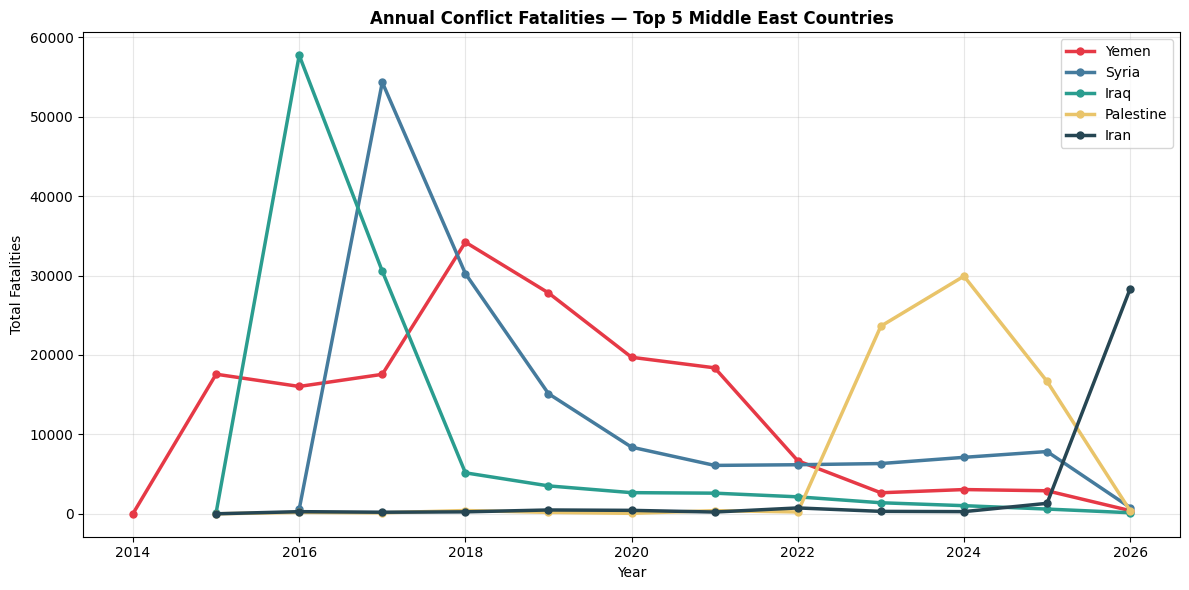

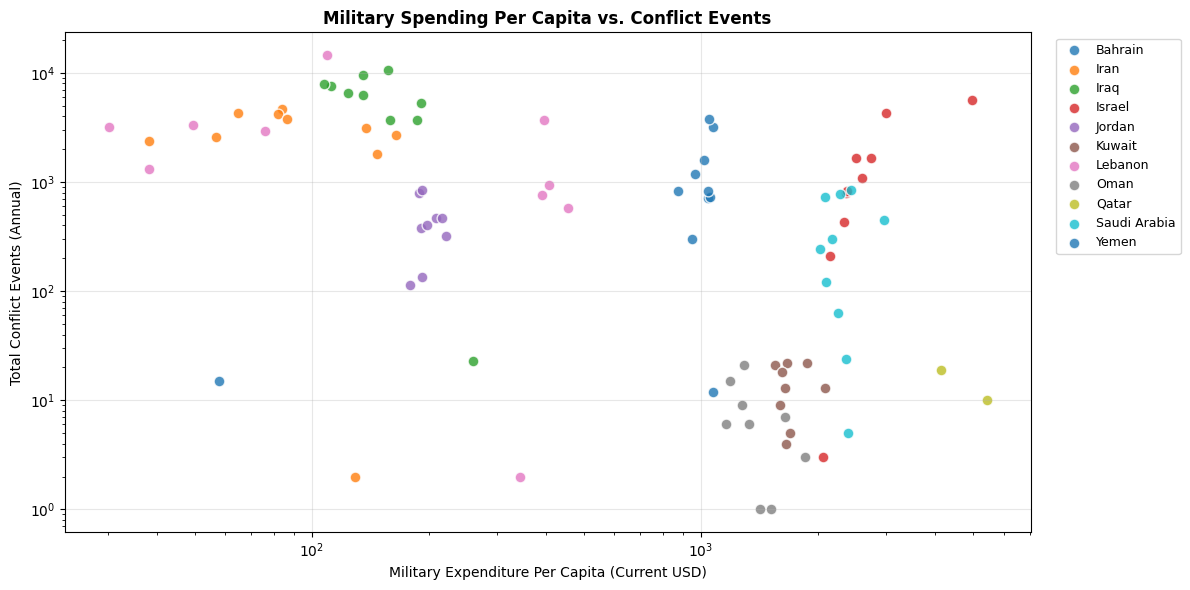

In [16]:
# some graphing:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

master = pd.read_csv('../Outputs/master_conflict_dataset.csv')

# --- Graph 1: Fatalities Over Time (Top 5) ---
top5 = master.groupby('COUNTRY')['total_fatalities'].sum().nlargest(5).index.tolist()
df_top5 = master[master['COUNTRY'].isin(top5)]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#264653']
for i, country in enumerate(top5):
    sub = df_top5[df_top5['COUNTRY'] == country].sort_values('YEAR')
    ax.plot(sub['YEAR'], sub['total_fatalities'], marker='o', linewidth=2.5,
            markersize=5, label=country, color=colors[i])
ax.set_xlabel('Year')
ax.set_ylabel('Total Fatalities')
ax.set_title('Annual Conflict Fatalities — Top 5 Middle East Countries', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Graph 2: Spending vs Events (Scatter) ---
df_scatter = master.dropna(subset=['milex_per_capita', 'total_events'])

fig, ax = plt.subplots(figsize=(12, 6))
for country in sorted(df_scatter['COUNTRY'].unique()):
    sub = df_scatter[df_scatter['COUNTRY'] == country]
    ax.scatter(sub['milex_per_capita'], sub['total_events'],
               label=country, s=60, alpha=0.8, edgecolors='white')
ax.set_xlabel('Military Expenditure Per Capita (Current USD)')
ax.set_ylabel('Total Conflict Events (Annual)')
ax.set_title('Military Spending Per Capita vs. Conflict Events', fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()